# Lab: Introduction to Image Enhancement — [COMPLETED]
---

## 1. Lab Overview & Summary
This laboratory provided a step-by-step practical implementation of **image enhancement** techniques. Starting with grayscale images, pixel value transformations were applied to systematically improve brightness, contrast, and overall visual quality. The core concepts were then successfully extended to color images, individual color channels, and HSV-based luminance enhancement.

### Core Concepts Covered & Implemented:
* **Spatial-Domain Processing & Point Operations:** Direct manipulation of pixel intensities.
* **Linear & Non-linear Transformations:** Implemented auto contrast, image negatives, scaling, log, and power-law (gamma) transformations.
* **Advanced Content:** Explored contrast stretching, intensity-level slicing, and bit-plane slicing.

> **Key Takeaway:** Image enhancement is inherently *subjective* and *application-oriented*. The processing pipeline must be tailored to make the resulting image optimal for its specific downstream application.

---

## 2. Completed Learning Outcomes
All targets for this laboratory exercise have been successfully achieved:

* [x] **Loaded & Displayed:** Successfully read and displayed grayscale and color images within the Google Colab environment.
* [x] **Analyzed Data:** Interpreted and manipulated image intensity values as raw numerical data arrays.
* [x] **Adjusted Brightness & Contrast:** Applied linear point transformations to alter visual properties.
* [x] **Inverted Images:** Generated crisp, photorealistic image negatives.
* [x] **Stretched Contrast:** Manually implemented auto-contrast and contrast stretching algorithms using minimum/maximum pixel boundaries.
* [x] **Applied Gamma Correction:** Implemented power-law (gamma) transformations to resolve non-linear luminance issues.
* [x] **Evaluated Parameters:** Compared varied enhancement parameters and interpreted their mathematical and visual effects.
* [x] **Inspected Histograms:** Generated and analyzed data histograms before and after transformations to track pixel redistribution.
* [x] **Manipulated Color Spaces:** Deconstructed standard BGR/RGB color channels in OpenCV and isolated the effects of modifying individual channels.
* [x] **Performed Color Enhancement:** Correctly enhanced color assets without distorting chromaticity by targeting the Value ($V$) channel in the HSV color space.
* [x] **Pipeline Design:** Programmed and justified a complete enhancement pipeline optimized for a real-world target image.

---

## 3. Final Technical Remarks & Conclusions
*(You can use this space to add a brief sentence about your findings, such as which gamma value worked best or a quick note on why HSV enhancement outperformed RGB channel scaling!)*


In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)



OpenCV version: 5.0.0
NumPy version: 2.5.3


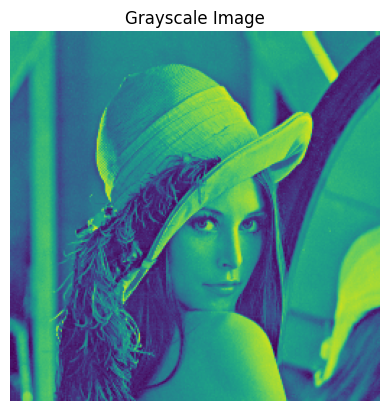

Shape: (256, 256)
Data type: uint8
Minimum: 26
Maximum: 242


In [68]:
# Read as grayscale

img = cv2.imread('lena_gray_256.tif', 0)

plt.imshow(img)
plt.axis('off')
plt.title("Grayscale Image")
plt.show()

print("Shape:", img.shape)
print("Data type:", img.dtype)
print("Minimum:", img.min())
print("Maximum:", img.max())


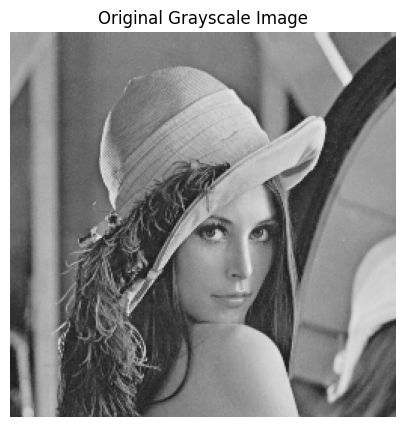

Shape: (256, 256)
Data type: uint8
Minimum: 26
Maximum: 242


In [69]:
# Display

plt.figure(figsize=(7,5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()


print("Shape:", img.shape)
print("Data type:", img.dtype)
print("Minimum:", img.min())
print("Maximum:", img.max())

In [70]:
# Investigate intensity statistics

print("Minimum intensity:", np.min(img))
print("Maximum intensity:", np.max(img))
print("Mean intensity:", np.mean(img))
print("Standard deviation:", np.std(img))

Minimum intensity: 26
Maximum intensity: 242
Mean intensity: 124.00845336914062
Standard deviation: 47.83815266771587


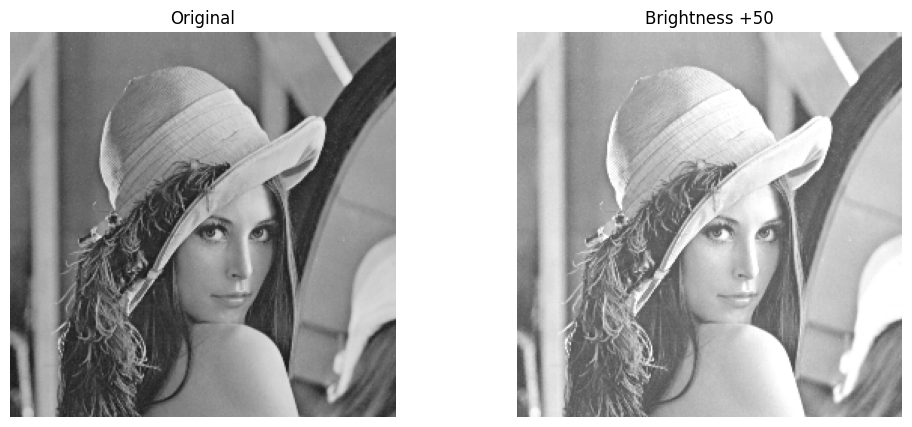

In [71]:
# Brightness Enhancement

brightness = 50
bright_img = img.astype(np.int16) + brightness
bright_img = np.clip(bright_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(bright_img, cmap='gray', vmin=0, vmax=255)
plt.title("Brightness +50"); plt.axis('off')
plt.show()



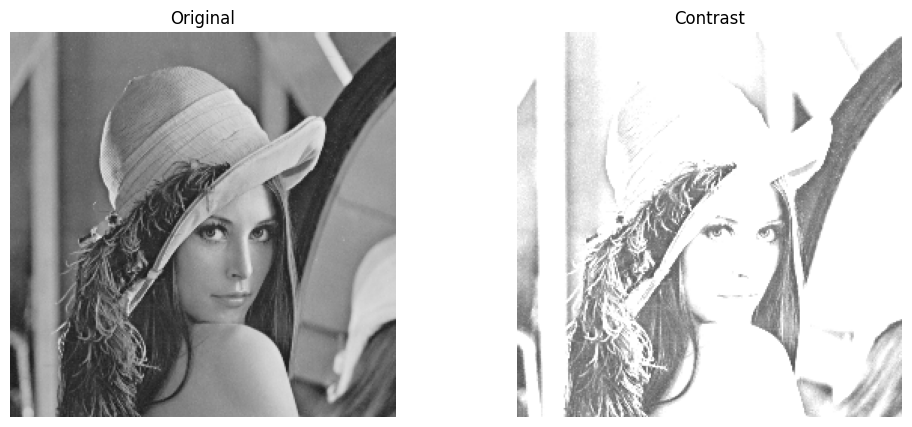

In [72]:
# Transformation c=2, b=32

contrast = 2
brightness = 32
contrast_img = img.astype(np.float32) * contrast + brightness
contrast_img = np.clip(contrast_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(contrast_img, cmap='gray', vmin=0, vmax=255)
plt.title("Contrast"); plt.axis('off')
plt.show()



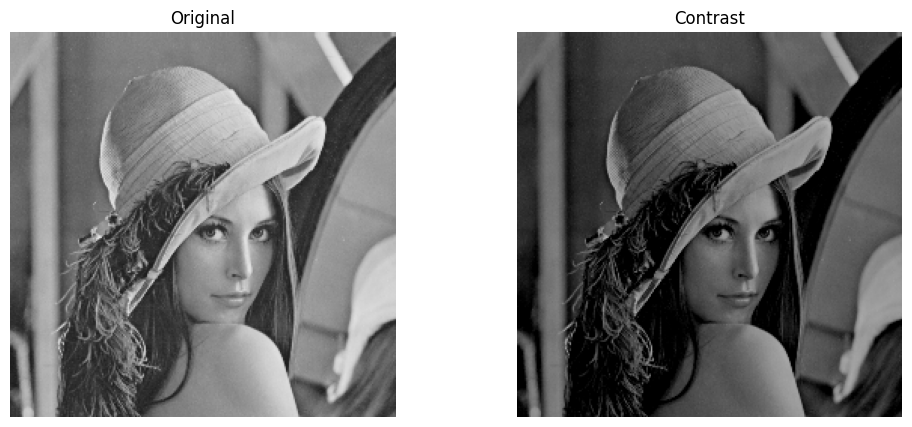

In [73]:
# Transformation c=1, b=-56

contrast = 1
brightness = -56
contrast_img = img.astype(np.float32) * contrast + brightness
contrast_img = np.clip(contrast_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(contrast_img, cmap='gray', vmin=0, vmax=255)
plt.title("Contrast"); plt.axis('off')
plt.show()

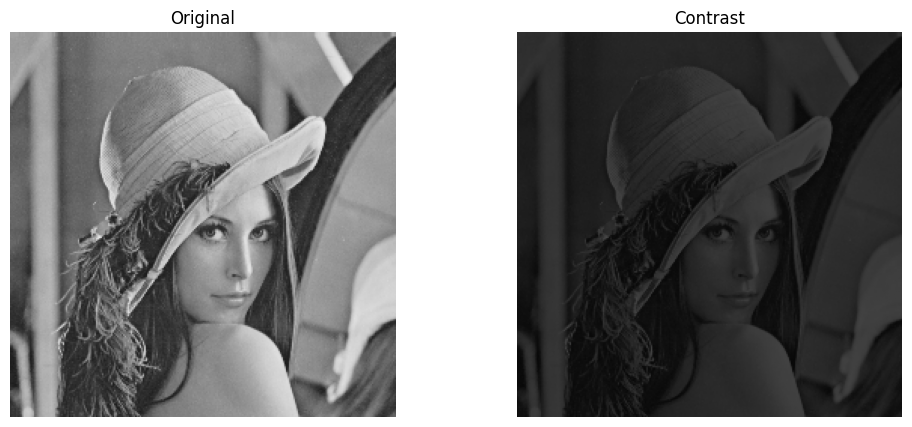

In [74]:
# Transformation c=0.3, b=0

contrast = 0.3
brightness = 0
contrast_img = img.astype(np.float32) * contrast + brightness
contrast_img = np.clip(contrast_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(contrast_img, cmap='gray', vmin=0, vmax=255)
plt.title("Contrast"); plt.axis('off')
plt.show()

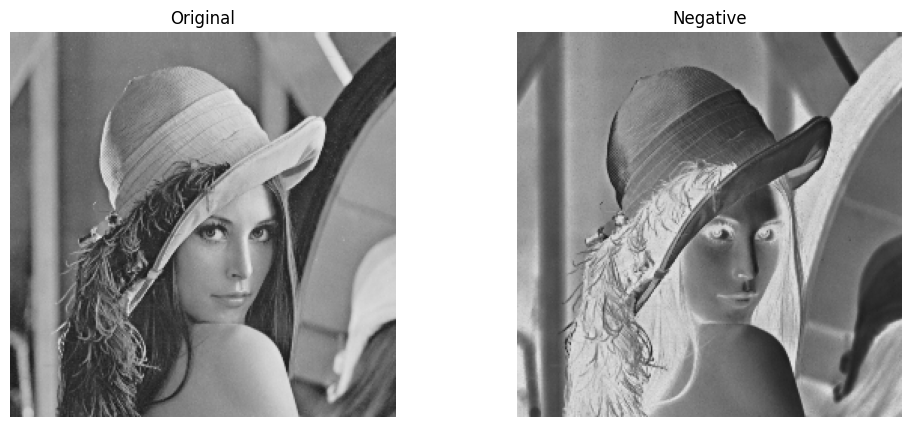

Original: 80
Negative: 175


In [75]:
# Image Negative

negative = 255 - img

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(negative, cmap='gray', vmin=0, vmax=255)
plt.title("Negative"); plt.axis('off')
plt.show()

r = 80
print("Original:", r)
print("Negative:", 255-r)


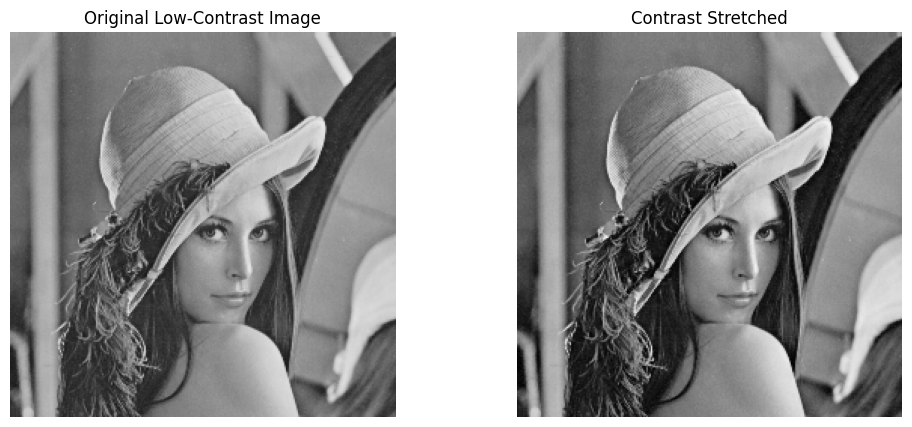

Original: 26 242
Enhanced: 0 255


In [76]:
# Auto Contrast / Contrast Stretching
# s = 255 × (r − r_min) / (r_max − r_min)

img_float = img.astype(np.float32)
r_min = img_float.min()
r_max = img_float.max()

stretched = 255 * (img_float - r_min) / (r_max - r_min)
stretched = np.clip(stretched, 0, 255).astype(np.uint8)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original Low-Contrast Image"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(stretched, cmap='gray', vmin=0, vmax=255)
plt.title("Contrast Stretched"); plt.axis('off')
plt.show()

print("Original:", img.min(), img.max())
print("Enhanced:", stretched.min(), stretched.max())



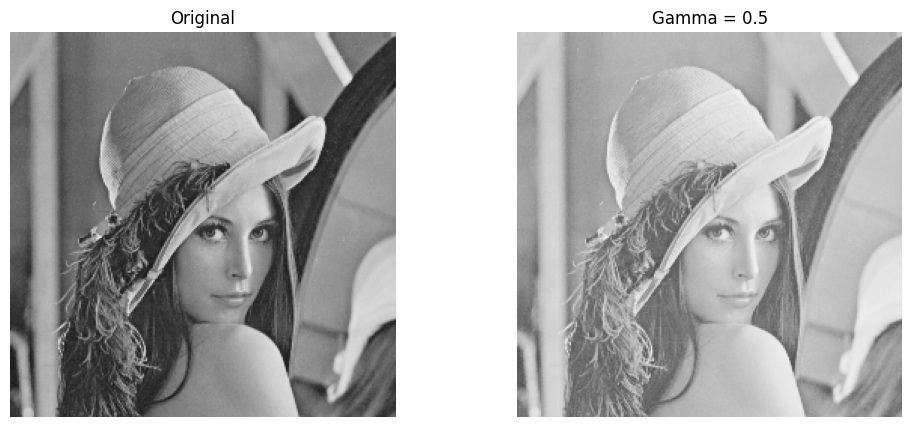

In [77]:
# Power-Law / Gamma Transformation

img_normalized = img / 255.0
gamma = 0.5

gamma_img = np.power(img_normalized, gamma)
gamma_img = np.uint8(gamma_img * 255)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(gamma_img, cmap='gray', vmin=0, vmax=255)
plt.title("Gamma = 0.5"); plt.axis('off')
plt.show()


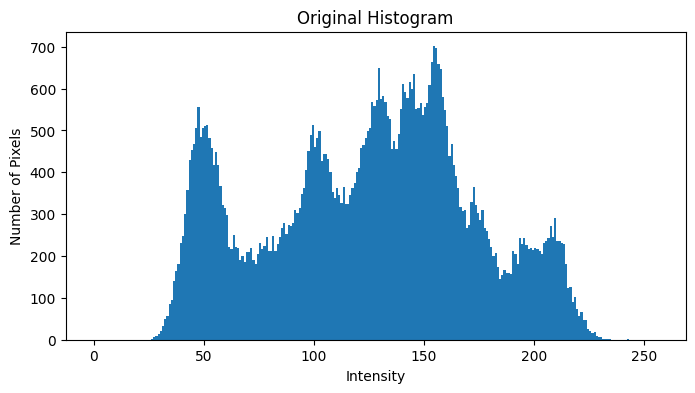

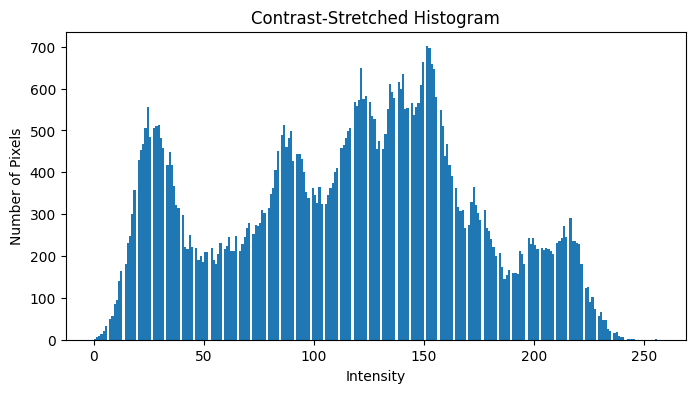

In [78]:
# Histogram Comparison

plt.figure(figsize=(8,4))
plt.hist(img.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")
plt.xlabel("Intensity"); plt.ylabel("Number of Pixels")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(stretched.ravel(), bins=256, range=[0,256])
plt.title("Contrast-Stretched Histogram")
plt.xlabel("Intensity"); plt.ylabel("Number of Pixels")
plt.show()


Shape: (408, 612, 3)
Data type: uint8


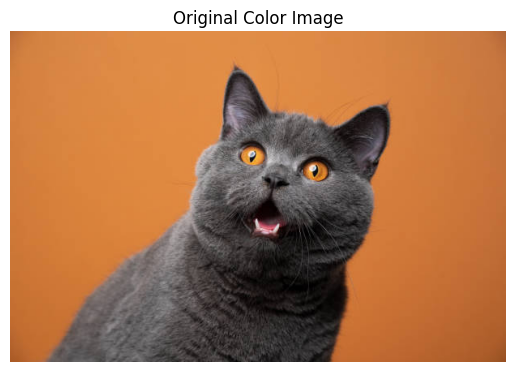

In [79]:
# Move to Color Images

color_img = cv2.imread('cat.jpg')
print("Shape:", color_img.shape)
print("Data type:", color_img.dtype)

color_rgb = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)
plt.imshow(color_rgb)
plt.title("Original Color Image")
plt.axis('off')
plt.show()



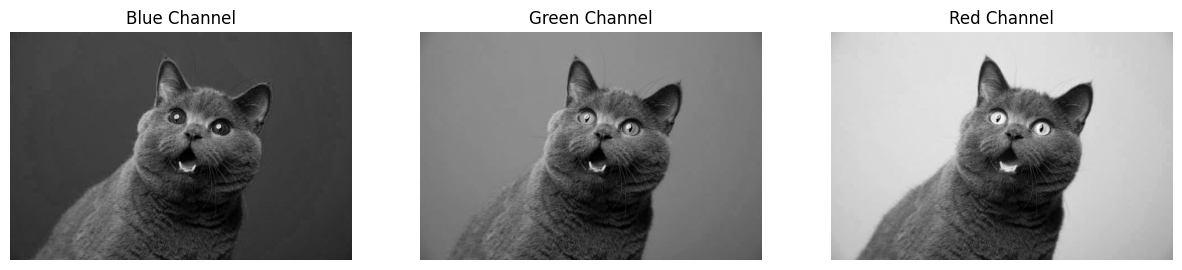

In [80]:
# Color Channels

B, G, R = cv2.split(color_img)

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.imshow(B, cmap='gray'); plt.title("Blue Channel"); plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(G, cmap='gray'); plt.title("Green Channel"); plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(R, cmap='gray'); plt.title("Red Channel"); plt.axis('off')
plt.show()



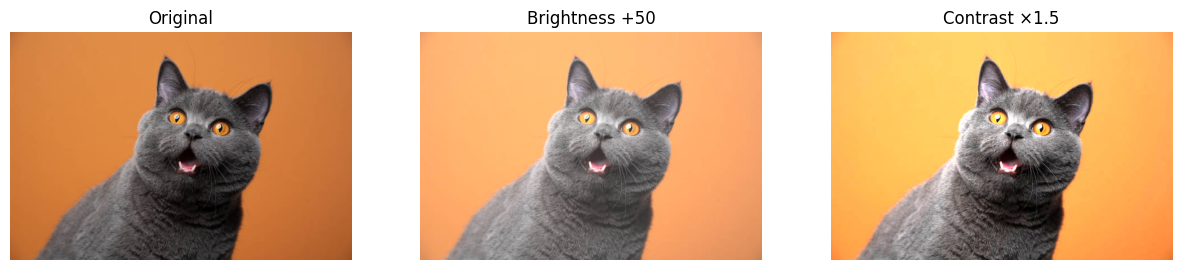

In [81]:
# Color Brightness and Contrast

color_bright = cv2.convertScaleAbs(color_img, alpha=1.0, beta=50)
color_bright_rgb = cv2.cvtColor(color_bright, cv2.COLOR_BGR2RGB)

color_contrast = cv2.convertScaleAbs(color_img, alpha=1.5, beta=0)
color_contrast_rgb = cv2.cvtColor(color_contrast, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(color_rgb); plt.title("Original"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(color_bright_rgb); plt.title("Brightness +50"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(color_contrast_rgb); plt.title("Contrast ×1.5"); plt.axis('off')
plt.show()


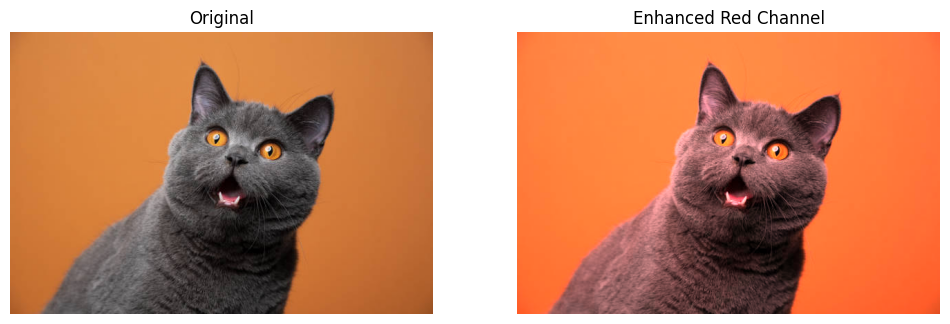

In [82]:
# Enhance One Color Channel

B, G, R = cv2.split(color_img)
R_enhanced = cv2.convertScaleAbs(R, alpha=1.5, beta=0)

enhanced_color = cv2.merge([B, G, R_enhanced])
enhanced_rgb = cv2.cvtColor(enhanced_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(color_rgb); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(enhanced_rgb); plt.title("Enhanced Red Channel"); plt.axis('off')
plt.show()



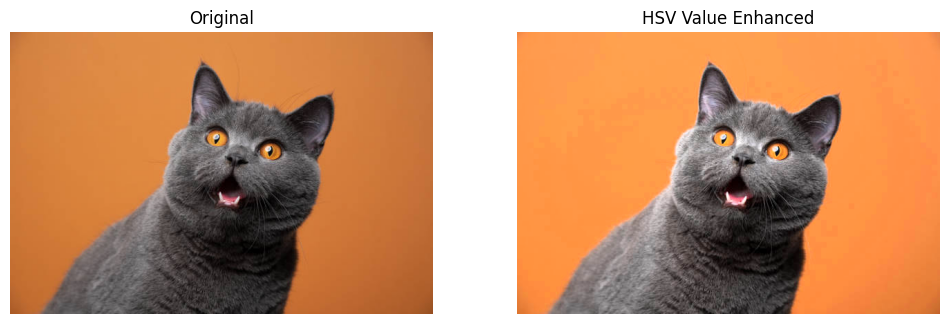

In [83]:
# Color Enhancement Using HSV

hsv = cv2.cvtColor(color_img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)
# print(H, S, V)

V_enhanced = cv2.convertScaleAbs(V, alpha=1.3, beta=0)
hsv_enhanced = cv2.merge([H, S, V_enhanced])

color_enhanced = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2BGR)
color_enhanced_rgb = cv2.cvtColor(color_enhanced, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(color_rgb); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(color_enhanced_rgb); plt.title("HSV Value Enhanced"); plt.axis('off')
plt.show()

